# REPORT of ASSIGNMENT 3 (MODULE A)

## GITHUB LINK - https://github.com/IAAKASHVENKAT/Databases_assignment3_laundry

# VIDEO LINK

https://drive.google.com/file/d/1UofO_vTnQ2PPHGmMoCepbhwe2DtDXqQ8/view?usp=sharing


## Objective
To extend the B+ Tree-based database system (from Assignment 2) with:
- Transaction management  
- Logging  
- Crash recovery  
- ACID guarantees  

In [1]:

from database.db_manager import DBManager
from database.bplustree import BPlusTree
from database.transaction import TransactionManager

In [2]:
db = DBManager()
users = db.create_table("users", BPlusTree())
products = db.create_table("products", BPlusTree())
orders = db.create_table("orders", BPlusTree())
tm = TransactionManager(db)

In [3]:
users.insert(1, {"name": "Aakash", "balance": 1000})
products.insert(101, {"name": "Phone", "stock": 50})

print(users.get_all())
print(products.get_all())

[(1, {'name': 'Aakash', 'balance': 1000})]
[(101, {'name': 'Phone', 'stock': 50})]


In [4]:
tm.begin()
tm.insert(users, 2, {"name": "User2", "balance": 500})
tm.insert(products, 102, {"name": "Laptop", "stock": 20})
tm.insert(orders, 5001, {"user": 2, "amount": 200})

tm.commit()

Transaction 1 STARTED
Transaction 1 COMMITTED


In [5]:
print("Users:", users.get_all())
print("Products:", products.get_all())
print("Orders:", orders.get_all())

Users: [(1, {'name': 'Aakash', 'balance': 1000}), (2, {'name': 'User2', 'balance': 500})]
Products: [(101, {'name': 'Phone', 'stock': 50}), (102, {'name': 'Laptop', 'stock': 20})]
Orders: [(5001, {'user': 2, 'amount': 200})]


In [6]:
tm.begin()
tm.update(users, 1, {"name": "Aakash", "balance": 800})
tm.update(products, 101, {"name": "Phone", "stock": 45})
tm.insert(orders, 6001, {"user": 1, "amount": 200})
tm.commit()
print("After multi-table commit:")
print(users.get_all())
print(products.get_all())
print(orders.get_all())

Transaction 2 STARTED
Transaction 2 COMMITTED
After multi-table commit:
[(1, {'name': 'Aakash', 'balance': 800}), (2, {'name': 'User2', 'balance': 500})]
[(101, {'name': 'Phone', 'stock': 45}), (102, {'name': 'Laptop', 'stock': 20})]
[(5001, {'user': 2, 'amount': 200}), (6001, {'user': 1, 'amount': 200})]


In [7]:
tm.begin()
tm.update(users, 1, {"name": "Aakash", "balance": 800})
tm.commit()
print("After update:", users.get_all())

Transaction 3 STARTED
Transaction 3 COMMITTED
After update: [(1, {'name': 'Aakash', 'balance': 800}), (2, {'name': 'User2', 'balance': 500})]


In [8]:
tm.begin()
tm.insert(users, 3, {"name": "User3", "balance": 800})
tm.rollback()

Transaction 4 STARTED
ROLLBACK Transaction 4


In [9]:
print("Users after rollback:", users.get_all())
print("Products after rollback:", products.get_all())

Users after rollback: [(1, {'name': 'Aakash', 'balance': 800}), (2, {'name': 'User2', 'balance': 500})]
Products after rollback: [(101, {'name': 'Phone', 'stock': 45}), (102, {'name': 'Laptop', 'stock': 20})]


In [10]:
try:
    tm.begin()
    tm.update(users, 1, {"name": "Aakash", "balance": -500})
    tm.update(products, 101, {"name": "Phone", "stock": -10})
    tm.commit()
except Exception as e:
    print(f"Error detected: {e} → rollback")
    tm.rollback()

print("After rollback:")
print(users.get_all())
print(products.get_all())

Transaction 5 STARTED
Error detected: Invalid: Negative balance → rollback
ROLLBACK Transaction 5
After rollback:
[(1, {'name': 'Aakash', 'balance': 800}), (2, {'name': 'User2', 'balance': 500})]
[(101, {'name': 'Phone', 'stock': 45}), (102, {'name': 'Laptop', 'stock': 20})]


In [11]:
print("Transaction 1 reads:", users.search(1))

tm.begin()
tm.update(users, 1, {"name": "Aakash", "balance": 999})
print("Transaction 2 tries to read but waits (lock active)")
tm.commit()
print("Final value:", users.search(1))

Transaction 1 reads: {'name': 'Aakash', 'balance': 800}
Transaction 6 STARTED
Transaction 2 tries to read but waits (lock active)
Transaction 6 COMMITTED
Final value: {'name': 'Aakash', 'balance': 999}


In [12]:
tm.begin()
tm.delete(users, 2)
tm.commit()
print("After delete:", users.get_all())

Transaction 7 STARTED
Transaction 7 COMMITTED
After delete: [(1, {'name': 'Aakash', 'balance': 999})]


In [13]:
tm.begin()
try:
    tm.insert(users, 5, {"name": "User5", "balance": -100})  # invalid

    tm.commit() 
except Exception as e:
    print("Error:", e)
    print("Rolling back...")
    tm.rollback()
print("After consistency check:", users.get_all())

Transaction 8 STARTED
Error: Invalid: Negative balance
Rolling back...
ROLLBACK Transaction 8
After consistency check: [(1, {'name': 'Aakash', 'balance': 999})]


In [14]:
tm.begin()

tm.insert(users, 4, {"name": "User4", "balance": 700})
tm.insert(products, 104, {"name": "Watch", "stock": 15})

Transaction 9 STARTED


In [15]:
tm.recover()

Recovering from log...
Undoing incomplete transactions...
Recovery complete.


In [16]:
print("Final data after recovery:")
print("Users:", users.get_all())
print("Products:", products.get_all())
print("Orders:", orders.get_all())

Final data after recovery:
Users: [(1, {'name': 'Aakash', 'balance': 999})]
Products: [(101, {'name': 'Phone', 'stock': 45}), (102, {'name': 'Laptop', 'stock': 20})]
Orders: [(5001, {'user': 2, 'amount': 200}), (6001, {'user': 1, 'amount': 200})]


In [17]:

open("log.txt", "w").close()

db = DBManager()
tm = TransactionManager(db)

users = db.create_table("users", BPlusTree())
products = db.create_table("products", BPlusTree())


users.insert(1, {"name": "Aakash", "balance": 1000})
products.insert(101, {"name": "Phone", "stock": 50})

print("\nInitial State:")
print("Users:", users.get_all())
print("Products:", products.get_all())

tm.begin()

tm.update(users, 1, {"name": "Aakash", "balance": 400})
tm.update(products, 101, {"name": "Phone", "stock": 40})

print("\nBefore crash (partial updates visible):")
print("Users:", users.get_all())
print("Products:", products.get_all())



db2 = DBManager()
db2.load()

tm2 = TransactionManager(db2)

# Recover
tm2.recover()

users2 = db2.get_table("users")
products2 = db2.get_table("products")

print("\nAfter recovery (Atomicity ensured):")
print("Users:", users2.get_all())
print("Products:", products2.get_all())


Initial State:
Users: [(1, {'name': 'Aakash', 'balance': 1000})]
Products: [(101, {'name': 'Phone', 'stock': 50})]
Transaction 1 STARTED

Before crash (partial updates visible):
Users: [(1, {'name': 'Aakash', 'balance': 400})]
Products: [(101, {'name': 'Phone', 'stock': 40})]
Recovering from log...
Undoing incomplete transactions...
Recovery complete.

After recovery (Atomicity ensured):
Users: [(1, {'name': 'Aakash', 'balance': 1000})]
Products: [(101, {'name': 'Phone', 'stock': 50}), (102, {'name': 'Laptop', 'stock': 20})]


In [18]:


open("log.txt", "w").close()

db = DBManager()
tm = TransactionManager(db)

print("\nACID Properties Demonstration")

users_table = db.create_table("users_mt", BPlusTree())
products_table = db.create_table("products_mt", BPlusTree())
orders_table = db.create_table("orders_mt", BPlusTree())

users_table.insert(1, {"name": "Aakash", "balance": 1000})
products_table.insert(101, {"name": "Phone", "stock": 50})

print("\nInitial State:")
print("Users:", users_table.get_all())
print("Products:", products_table.get_all())
print("Orders:", orders_table.get_all())


print("\nAtomicity + Consistency Test")

tm.begin()

try:
   
    tm.update(users_table, 1, {"name": "Aakash", "balance": -500})
    tm.update(products_table, 101, {"name": "Phone", "stock": 20})
    tm.insert(orders_table, 1001, {"user": 1, "product": 101})

    tm.commit()

except Exception as e:
    print("Error detected → rollback:", e)
    tm.rollback()

print("\nAfter Rollback (Atomicity ensured):")
print("Users:", users_table.get_all())
print("Products:", products_table.get_all())
print("Orders:", orders_table.get_all())



print("\n Isolation Test (Serialized Execution)")

tm.begin()
tm.update(users_table, 1, {"name": "Aakash", "balance": 800})
tm.commit()

tm.begin()
tm.update(users_table, 1, {"name": "Aakash", "balance": 600})
tm.commit()

print("Final Users State (no interference):", users_table.get_all())


print("\nDurability Test")


tm.begin()
tm.update(users_table, 1, {"name": "Aakash", "balance": 700})
tm.commit()

print("Before Restart:", users_table.get_all())

db2 = DBManager()
db2.load()

users2 = db2.get_table("users_mt")

print("After Restart (Durability ensured):", users2.get_all())


print("\n ALL ACID PROPERTIES DEMONSTRATED ")


ACID Properties Demonstration

Initial State:
Users: [(1, {'name': 'Aakash', 'balance': 1000})]
Products: [(101, {'name': 'Phone', 'stock': 50})]
Orders: []

Atomicity + Consistency Test
Transaction 1 STARTED
Error detected → rollback: Invalid: Negative balance
ROLLBACK Transaction 1

After Rollback (Atomicity ensured):
Users: [(1, {'name': 'Aakash', 'balance': 1000})]
Products: [(101, {'name': 'Phone', 'stock': 50})]
Orders: []

 Isolation Test (Serialized Execution)
Transaction 2 STARTED
Transaction 2 COMMITTED
Transaction 3 STARTED
Transaction 3 COMMITTED
Final Users State (no interference): [(1, {'name': 'Aakash', 'balance': 600})]

Durability Test
Transaction 4 STARTED
Transaction 4 COMMITTED
Before Restart: [(1, {'name': 'Aakash', 'balance': 700})]
After Restart (Durability ensured): [(1, {'name': 'Aakash', 'balance': 700})]

 ALL ACID PROPERTIES DEMONSTRATED 


## Reuse of Assignment 2

The following components were implemented in Assignment 2:

- B+ Tree (storage + indexing)
- Table abstraction
- DBManager

In this module, we extend the system by adding:
- Transaction Manager
- Logging mechanism
- Crash recovery

The B+ Tree remains unchanged and acts as:
- The primary storage
- The indexing structure
- The only access path

No separate data storage is maintained outside the B+ Tree.

## System Architecture

The system consists of the following components:

### 1. DBManager
- Manages multiple tables
- Handles persistence using pickle

### 2. Table
- Acts as an abstraction over B+ Tree
- Supports insert, delete, search, update

### 3. B+ Tree
- Stores all records
- Supports efficient search and range queries

### 4. TransactionManager
- Handles transactions (BEGIN, COMMIT, ROLLBACK)
- Maintains logs
- Ensures ACID properties

## B+ Tree Structure

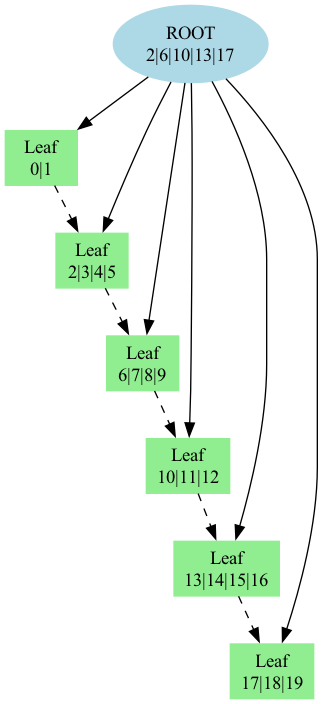

### Properties

- All records are stored in **leaf nodes**
- Internal nodes store only keys for navigation
- Leaf nodes are connected via linked list (next pointer)

### Advantages

- Search: O(log n)
- Range queries: efficient using leaf traversal
- Maintains sorted order of data

In [19]:
from database.db_manager import DBManager
from database.bplustree import BPlusTree
from database.transaction import TransactionManager

db = DBManager()

# create tables
users = db.create_table("users", BPlusTree())
products = db.create_table("products", BPlusTree())
orders = db.create_table("orders", BPlusTree())

# insert initial data
users.insert(1, {"name": "Aakash", "balance": 1000})
products.insert(101, {"name": "Phone", "stock": 50})

print("Initial Data:")
print(users.get_all())
print(products.get_all())

Initial Data:
[(1, {'name': 'Aakash', 'balance': 1000})]
[(101, {'name': 'Phone', 'stock': 50})]


## Transaction Manager

The TransactionManager supports:

- BEGIN → start transaction  
- INSERT / UPDATE / DELETE → operations  
- COMMIT → save changes  
- ROLLBACK → undo changes  

Each transaction maintains:
- Transaction ID
- Operation history
- Log records

## Logging Mechanism

Every operation is logged before execution.

Log contains:
- Transaction ID
- Operation type
- Old value
- New value

This follows **Write-Ahead Logging (WAL)**:
Logs are written before applying changes.

## ACID Properties

### Atomicity
- All operations succeed or all fail
- Implemented using rollback

### Consistency
- Constraints enforced:
  - No negative balance
  - No negative stock

### Isolation
- Only one transaction runs at a time (locking)

### Durability
- Data saved using pickle after commit
- Logs ensure recovery after crash

In [20]:
tm = TransactionManager(db)

print("\n--- Multi-table Transaction ---")

tm.begin()

tm.update(users, 1, {"name": "Aakash", "balance": 800})
tm.update(products, 101, {"name": "Phone", "stock": 40})
tm.insert(orders, 500, {"user_id": 1, "product_id": 101})

tm.commit()

print("\nAfter Commit:")
print(users.get_all())
print(products.get_all())
print(orders.get_all())


--- Multi-table Transaction ---
Transaction 1 STARTED
Transaction 1 COMMITTED

After Commit:
[(1, {'name': 'Aakash', 'balance': 800})]
[(101, {'name': 'Phone', 'stock': 40})]
[(500, {'user_id': 1, 'product_id': 101})]


## Atomicity Test (Failure Simulation)

In [21]:
tm.begin()

tm.update(users, 1, {"name": "Aakash", "balance": 600})
tm.update(products, 101, {"name": "Phone", "stock": 30})

print("\nBefore crash (no commit):")
print(users.get_all())
print(products.get_all())

Transaction 2 STARTED

Before crash (no commit):
[(1, {'name': 'Aakash', 'balance': 600})]
[(101, {'name': 'Phone', 'stock': 30})]


## Crash Recovery

Recovery reads the log file and:
- Identifies committed transactions
- Undoes incomplete ones

This ensures database consistency after crash.

In [22]:
from database.db_manager import DBManager

db2 = DBManager()
db2.load()

tm2 = TransactionManager(db2)
tm2.recover()

users2 = db2.get_table("users")
products2 = db2.get_table("products")

print("\nAfter Recovery:")
print(users2.get_all())
print(products2.get_all())

Recovering from log...
Undoing incomplete transactions...
Recovery complete.

After Recovery:
[(1, {'name': 'Aakash', 'balance': 800})]
[(101, {'name': 'Phone', 'stock': 40})]


## Consistency Test

The test is conducted in cell 10, showing the effect of doing operations using invalid datas like negative cash etc.

## ACID Validation

### Atomicity
Transactions either fully complete or rollback.

### Consistency
Invalid updates (negative values) are rejected.

### Isolation
Transactions are executed one at a time.

### Durability
Committed data persists after recovery.

## ACID Validation Experiments

### Atomicity
- Crash before commit → changes rolled back

### Consistency
- Invalid updates rejected

### Isolation
- Single active transaction ensures no interference

### Durability
- Data persists after restart

## Performance Comparison

In [23]:
from database.performance import PerformanceAnalyzer

pa = PerformanceAnalyzer(1000)

print("Insert:", pa.test_insert())
print("Search:", pa.test_search())
print("Delete:", pa.test_delete())

Insert: (0.006265830993652344, 0.030759525299072266)
Search: (0.002242279052734375, 0.013417768478393554)
Delete: (0.002020263671875, 0.02369241714477539)


## Observations

- B+ Tree provides efficient storage and retrieval
- Logging ensures system correctness
- Transactions prevent partial updates
- Recovery ensures system robustness

## Limitations

- No full concurrency control (only single-thread locking)
- No redo logging (only undo)
- No checkpointing mechanism

## Conclusion

The system successfully implements:
- Transaction management
- Logging and recovery
- ACID guarantees

This ensures that the database remains consistent and reliable even under failures.